# Santander Customer Transaction Prediction – professioneller Modellvergleich (v5)

## Ziel

Dieses Notebook vergleicht überwachte Klassifikationsmodelle unter einem einheitlichen, leakage-armen Evaluationsdesign und trennt die explorative K-Means-Analyse klar davon.

**Primäre Modellmetrik:** PR-AUC / Average Precision, weil nur rund 10 % der Beobachtungen positiv sind.  
**Sekundäre Metrik:** ROC-AUC.  
**Ergänzend:** Log Loss, Brier Score, Laufzeit, Kalibrierung und schwellenwertabhängige Kennzahlen.

## Methodische Leitplanken

- Ein neuer stratifizierter 80/20-Holdout wird erzeugt und in diesem Notebook **nicht ausgewertet**.
- Alle überwachten Modelle verwenden dieselben äußeren fünf Folds.
- Hyperparameter werden ausschließlich innerhalb des jeweiligen äußeren Trainingsfolds gewählt.
- Jede Beobachtung erhält genau eine Out-of-Fold-Vorhersage je Klassifikator.
- K-Means bleibt eine explorative, unüberwachte Segmentierungsanalyse und wird nicht als Klassifikator gerankt.
- Der finale Holdout darf erst nach festgeschriebener Modell-, Kalibrierungs- und Schwellenwertentscheidung einmal geöffnet werden.

> Ausführungshinweis: Kernel neu starten und anschließend alle Zellen von oben nach unten ausführen. Die vollständige Nested-CV ist absichtlich rechenintensiv.


## 1. Setup, Versionen und reproduzierbare Konfiguration


In [1]:
from pathlib import Path
from time import perf_counter
import hashlib
import json
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy
import sklearn
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42
FINAL_HOLDOUT_RANDOM_STATE = 20260808
OUTER_SPLITS = 5
INNER_SPLITS = 2
PRIMARY_METRIC = "PR-AUC"
FILE_PATH = Path.cwd() / "dataset"

# Bewusst begrenzte, vorab definierte Suchräume.
LOGISTIC_C_VALUES = [0.1, 1.0]
KNN_K_VALUES = [21, 51, 101]
KNN_WEIGHT_VALUES = ["uniform", "distance"]
KNN_OUTER_TRAIN_CAP = 10_000
KNN_INNER_EVAL_SIZE = 5_000
KMEANS_K_VALUES = [2, 3, 5, 7]
KMEANS_SEEDS = [42, 43, 44]
BOOTSTRAP_REPETITIONS = 200

versions = pd.DataFrame({
    "Software": ["Python", "pandas", "NumPy", "SciPy", "Matplotlib", "scikit-learn"],
    "Version": [
        platform.python_version(), pd.__version__, np.__version__, scipy.__version__,
        matplotlib.__version__, sklearn.__version__
    ],
})
display(versions)
print("Primärmetrik:", PRIMARY_METRIC)
print("Seeds:", {"global": RANDOM_STATE, "final_holdout": FINAL_HOLDOUT_RANDOM_STATE})


,Software,Version
0,Python,3.13.5
1,pandas,3.0.5
2,NumPy,2.5.1
3,SciPy,1.18.0
4,Matplotlib,3.11.1
5,scikit-learn,1.9.0


Primärmetrik: PR-AUC
Seeds: {'global': 42, 'final_holdout': 20260808}


## 2. Daten laden und Struktur validieren


In [2]:
if not FILE_PATH.is_file():
    raise FileNotFoundError("Die Datei 'dataset' muss im gleichen Ordner wie das Notebook liegen.")

with open(FILE_PATH, "rb") as handle:
    header = handle.read(2_000)

if b"@relation" not in header.lower() and b"@attribute" not in header.lower():
    raise ValueError("Die Datei wurde nicht als erwartete ARFF-Datei erkannt.")

from scipy.io import arff

raw_data, metadata = arff.loadarff(FILE_PATH)
df = pd.DataFrame(raw_data)
for column in df.select_dtypes(include="object").columns:
    df[column] = df[column].map(
        lambda value: value.decode("utf-8") if isinstance(value, bytes) else value
    )

TARGET = "target"
feature_columns = [column for column in df.columns if column.startswith("var_")]
assert df.shape == (200_000, 201), f"Unerwartete Form: {df.shape}"
assert len(feature_columns) == 200, f"Unerwartete Feature-Anzahl: {len(feature_columns)}"
assert TARGET in df.columns

target_mapping = {"False": 0, "True": 1, False: 0, True: 1, 0: 0, 1: 1}
y = df[TARGET].map(target_mapping)
if y.isna().any():
    raise ValueError(f"Unbekannte Targetwerte: {df.loc[y.isna(), TARGET].unique().tolist()}")

y = y.astype("int8")
X = df[feature_columns].astype("float32")

file_hash = hashlib.sha256(FILE_PATH.read_bytes()).hexdigest()
data_manifest = pd.DataFrame({
    "Merkmal": ["Format", "Zeilen", "Features", "Target", "Dateigröße [MiB]", "SHA-256"],
    "Wert": ["ARFF", len(df), len(feature_columns), TARGET,
             f"{FILE_PATH.stat().st_size / 1024**2:,.2f}", file_hash],
})
display(data_manifest)
display(df.head(3))


,Merkmal,Wert
0,Format,ARFF
1,Zeilen,200000
2,Features,200
3,Target,target
4,Dateigröße [MiB],298.39
5,SHA-256,06d49fb4b311c72a16686a0aeda4f15167872bf550cb8c...


,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,var_10,var_11,var_12,var_13,var_14,var_15,var_16,var_17,var_18,var_19,...,var_181,var_182,var_183,var_184,var_185,var_186,var_187,var_188,var_189,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199,target
0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,-4.9200,5.7470,2.9252,3.1821,14.0137,0.5745,8.7989,14.5691,5.7487,-7.2393,4.2840,30.7133,...,9.0164,3.0657,14.3691,25.8398,5.8764,11.8411,-19.7159,17.5743,0.5857,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914,False
1,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,3.1468,8.0851,-0.4032,8.0585,14.0239,8.4135,5.4345,13.7003,13.8275,-15.5849,7.8000,28.5708,...,9.4878,-14.9100,9.4245,22.5441,-4.8622,7.6543,-15.9319,13.3175,-0.3566,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518,False
2,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,-4.9193,5.9525,-0.3249,-11.2648,14.1929,7.3124,7.5244,14.6472,7.6782,-1.7395,4.7011,20.4775,...,9.3908,-13.2648,3.1545,23.0866,-5.3000,5.3745,-6.2660,10.1934,-0.8417,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965,False


## 3. Prospektiv gesperrter finaler Holdout

Der Holdout wird nur erzeugt und gezählt. Seine Zielverteilung, Vorhersagen und Metriken werden in dieser Version nicht betrachtet.


In [3]:
from sklearn.model_selection import train_test_split

all_indices = np.arange(len(X))
dev_indices, final_holdout_indices = train_test_split(
    all_indices,
    test_size=0.20,
    stratify=y,
    random_state=FINAL_HOLDOUT_RANDOM_STATE,
)

X_dev = X.iloc[dev_indices].reset_index(drop=True)
y_dev = y.iloc[dev_indices].reset_index(drop=True)
X_final_holdout = X.iloc[final_holdout_indices].reset_index(drop=True)
y_final_holdout = y.iloc[final_holdout_indices].reset_index(drop=True)

assert X_dev.shape == (160_000, 200)
assert X_final_holdout.shape == (40_000, 200)
assert set(dev_indices).isdisjoint(set(final_holdout_indices))

display(pd.DataFrame({
    "Teil": ["Entwicklungsdaten", "Finaler Holdout"],
    "n": [len(X_dev), len(X_final_holdout)],
    "Verwendung": ["EDA, Tuning und CV", "GESPERRT – keine Auswertung in v5"],
}))
print("Finaler Holdout: GESPERRT")


,Teil,n,Verwendung
0,Entwicklungsdaten,160000,"EDA, Tuning und CV"
1,Finaler Holdout,40000,GESPERRT – keine Auswertung in v5


Finaler Holdout: GESPERRT


## 4. Kompakte EDA und Modellierungsfolgen


In [4]:
dev_with_target = X_dev.copy()
dev_with_target[TARGET] = y_dev.to_numpy()

missing_total = int(dev_with_target.isna().sum().sum())
inf_total = int(np.isinf(X_dev.to_numpy()).sum())
duplicate_rows = int(dev_with_target.duplicated().sum())
constant_features = X_dev.columns[X_dev.nunique() <= 1].tolist()

feature_std = X_dev.std()
std_ratio = float(feature_std.max() / feature_std.min())

target_table = pd.DataFrame({
    "Anzahl": y_dev.value_counts().sort_index(),
    "Anteil [%]": y_dev.value_counts(normalize=True).sort_index() * 100,
})
target_table.index = ["False", "True"]

display(pd.DataFrame({
    "Prüfung": ["Missing Values", "±Inf", "Doppelte Zeilen", "Konstante Features"],
    "Anzahl": [missing_total, inf_total, duplicate_rows, len(constant_features)],
}))
display(target_table)
display(pd.DataFrame({
    "Kennzahl": ["Max/Min Feature-Standardabweichung", "Positive Basisrate / PR-AUC-Referenz"],
    "Wert": [std_ratio, float(y_dev.mean())],
}))

assert missing_total == 0 and inf_total == 0 and not constant_features
print("Folge: keine Imputation; Scaling bleibt für distanz- und linearbasierte Modelle notwendig.")


,Prüfung,Anzahl
0,Missing Values,0
1,±Inf,0
2,Doppelte Zeilen,0
3,Konstante Features,0


,Anzahl,Anteil [%]
False,143922,89.9513
True,16078,10.0488


,Kennzahl,Wert
0,Max/Min Feature-Standardabweichung,"2,981.6843"
1,Positive Basisrate / PR-AUC-Referenz,0.1005


Folge: keine Imputation; Scaling bleibt für distanz- und linearbasierte Modelle notwendig.


In [5]:
pearson_target = X_dev.corrwith(y_dev)
mask_negative = y_dev.eq(0)
mask_positive = y_dev.eq(1)

cohens_d = {}
for column in X_dev.columns:
    negative = X_dev.loc[mask_negative, column]
    positive = X_dev.loc[mask_positive, column]
    n0, n1 = len(negative), len(positive)
    s0, s1 = negative.std(ddof=1), positive.std(ddof=1)
    pooled_sd = np.sqrt(((n0 - 1) * s0**2 + (n1 - 1) * s1**2) / (n0 + n1 - 2))
    cohens_d[column] = (positive.mean() - negative.mean()) / pooled_sd

association = pd.DataFrame({
    "Pearson": pearson_target,
    "Cohen's d": pd.Series(cohens_d),
})
association["|Pearson|"] = association["Pearson"].abs()
association["|Cohen's d|"] = association["Cohen's d"].abs()
display(association.nlargest(15, "|Cohen's d|")[["Pearson", "Cohen's d"]])

feature_corr = X_dev.corr()
upper_corr = feature_corr.where(
    np.triu(np.ones(feature_corr.shape, dtype=bool), k=1)
).stack()
print(f"Maximales |r| zwischen Features: {upper_corr.abs().max():.4f}")
print(f"Maximales |Cohen's d|: {association["|Cohen's d|"].max():.4f}")
print("Interpretation: schwache univariate Effekte, kaum lineare Redundanz und 200 Dimensionen.")


,Pearson,Cohen's d
var_81,-0.0800,-0.2671
var_139,-0.0731,-0.2438
var_12,-0.0701,-0.2338
var_6,0.0693,0.2309
var_146,-0.0655,-0.2184
var_110,0.0647,0.2155
var_53,0.0636,0.2118
var_26,0.0627,0.2088
var_22,0.0617,0.2058
var_76,-0.0615,-0.2049


Maximales |r| zwischen Features: 0.0111
Maximales |Cohen's d|: 0.2671
Interpretation: schwache univariate Effekte, kaum lineare Redundanz und 200 Dimensionen.


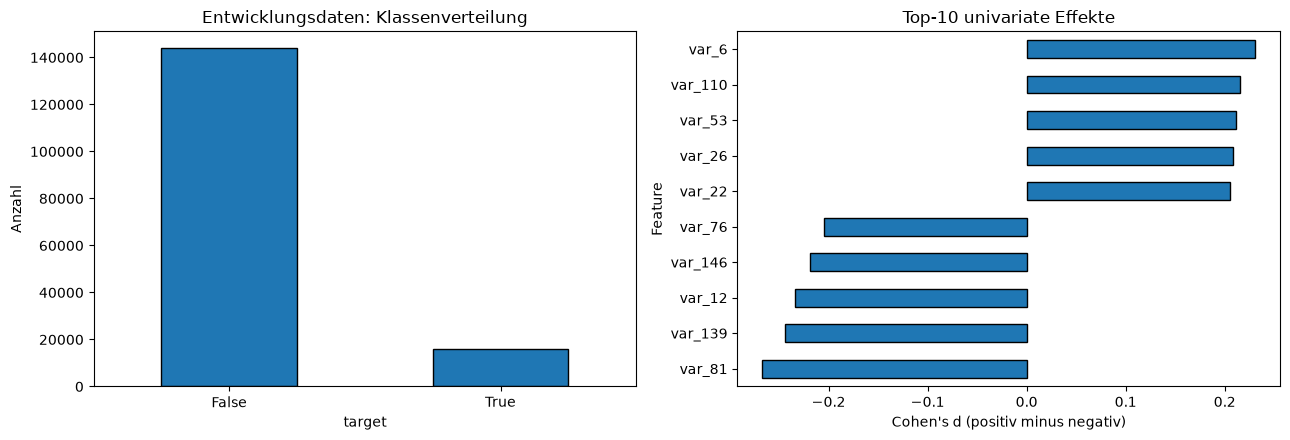

In [6]:
top_features_eda = association.nlargest(10, "|Cohen's d|").sort_values("Cohen's d")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

target_table["Anzahl"].plot(kind="bar", ax=axes[0], edgecolor="black")
axes[0].set_title("Entwicklungsdaten: Klassenverteilung")
axes[0].set_xlabel("target")
axes[0].set_ylabel("Anzahl")
axes[0].tick_params(axis="x", rotation=0)

top_features_eda["Cohen's d"].plot(kind="barh", ax=axes[1], edgecolor="black")
axes[1].set_title("Top-10 univariate Effekte")
axes[1].set_xlabel("Cohen's d (positiv minus negativ)")
axes[1].set_ylabel("Feature")

plt.tight_layout()
plt.show()


### EDA-Fazit

- Rund 10 % positive Fälle: PR-AUC ist die primäre Auswahlmetrik.
- Die Feature-Streuungen unterscheiden sich um ungefähr den oben berechneten Faktor – Scaling ist für kNN und logistische Regression erforderlich.
- Einzelne Features trennen nur schwach; die Kombination vieler Merkmale ist entscheidend.
- Fast keine paarweise lineare Feature-Korrelation; PCA ist für kNN dennoch als Dimensionsreduktion interessant.
- Keine pauschale Zeilen- oder Ausreißerentfernung ohne fachliche Bedeutung der anonymisierten Features.


## 5. Einheitliches äußeres Evaluationsdesign


In [7]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    log_loss,
    brier_score_loss,
)

outer_cv = StratifiedKFold(
    n_splits=OUTER_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
outer_splits = list(outer_cv.split(X_dev, y_dev))

fold_manifest = []
for fold, (train_idx, validation_idx) in enumerate(outer_splits, start=1):
    fold_manifest.append({
        "Fold": fold,
        "Train n": len(train_idx),
        "Validation n": len(validation_idx),
        "Train positiv [%]": 100 * y_dev.iloc[train_idx].mean(),
        "Validation positiv [%]": 100 * y_dev.iloc[validation_idx].mean(),
    })

fold_manifest = pd.DataFrame(fold_manifest)
display(fold_manifest)

def probability_metrics(y_true, probabilities):
    probabilities = np.clip(np.asarray(probabilities, dtype=float), 1e-7, 1 - 1e-7)
    return {
        "PR-AUC": average_precision_score(y_true, probabilities),
        "ROC-AUC": roc_auc_score(y_true, probabilities),
        "Log Loss": log_loss(y_true, probabilities),
        "Brier": brier_score_loss(y_true, probabilities),
    }

oof_predictions = pd.DataFrame(index=np.arange(len(X_dev)))
fold_results = []
model_runtime = {}
model_details = {}


,Fold,Train n,Validation n,Train positiv [%],Validation positiv [%]
0,1,128000,32000,10.0492,10.0469
1,2,128000,32000,10.0492,10.0469
2,3,128000,32000,10.0484,10.0500
3,4,128000,32000,10.0484,10.0500
4,5,128000,32000,10.0484,10.0500


## 6. Baseline 1 – DummyClassifier


In [8]:
from sklearn.dummy import DummyClassifier

model_name = "Dummy (Prior)"
start_model = perf_counter()
oof = np.full(len(X_dev), np.nan)

for fold, (train_idx, validation_idx) in enumerate(outer_splits, start=1):
    start_fold = perf_counter()
    model = DummyClassifier(strategy="prior")
    model.fit(X_dev.iloc[train_idx], y_dev.iloc[train_idx])
    probabilities = model.predict_proba(X_dev.iloc[validation_idx])[:, 1]
    oof[validation_idx] = probabilities
    fold_results.append({
        "Modell": model_name,
        "Fold": fold,
        **probability_metrics(y_dev.iloc[validation_idx], probabilities),
        "Sekunden": perf_counter() - start_fold,
    })

assert not np.isnan(oof).any()
oof_predictions[model_name] = oof
model_runtime[model_name] = perf_counter() - start_model
display(pd.DataFrame([probability_metrics(y_dev, oof)], index=[model_name]))


,PR-AUC,ROC-AUC,Log Loss,Brier
Dummy (Prior),0.1005,0.5000,0.3262,0.0904


## 7. Baseline 2 – logistische Regression mit innerer CV


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

model_name = "Logistische Regression"
start_model = perf_counter()
oof = np.full(len(X_dev), np.nan)
selected_parameters = []

for fold, (train_idx, validation_idx) in enumerate(outer_splits, start=1):
    start_fold = perf_counter()
    inner_cv = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=RANDOM_STATE + 100 + fold,
    )
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(solver="lbfgs", max_iter=1_000, random_state=RANDOM_STATE)),
    ])
    search = GridSearchCV(
        estimator=pipeline,
        param_grid={
            "model__C": LOGISTIC_C_VALUES,
            "model__class_weight": [None, "balanced"],
        },
        scoring="average_precision",
        cv=inner_cv,
        refit=True,
        n_jobs=-1,
        return_train_score=False,
    )
    search.fit(X_dev.iloc[train_idx], y_dev.iloc[train_idx])
    probabilities = search.predict_proba(X_dev.iloc[validation_idx])[:, 1]
    oof[validation_idx] = probabilities
    selected_parameters.append({"Fold": fold, **search.best_params_, "Inner PR-AUC": search.best_score_})
    fold_results.append({
        "Modell": model_name,
        "Fold": fold,
        **probability_metrics(y_dev.iloc[validation_idx], probabilities),
        "Sekunden": perf_counter() - start_fold,
    })
    print(f"Fold {fold}: PR-AUC={average_precision_score(y_dev.iloc[validation_idx], probabilities):.4f} | {search.best_params_}")

assert not np.isnan(oof).any()
oof_predictions[model_name] = oof
model_runtime[model_name] = perf_counter() - start_model
model_details[model_name] = pd.DataFrame(selected_parameters)
display(model_details[model_name])


Fold 1: PR-AUC=0.5077 | {'model__C': 0.1, 'model__class_weight': None}
Fold 2: PR-AUC=0.5080 | {'model__C': 0.1, 'model__class_weight': None}
Fold 3: PR-AUC=0.4997 | {'model__C': 0.1, 'model__class_weight': None}
Fold 4: PR-AUC=0.5100 | {'model__C': 0.1, 'model__class_weight': None}
Fold 5: PR-AUC=0.5085 | {'model__C': 0.1, 'model__class_weight': None}


,Fold,model__C,model__class_weight,Inner PR-AUC
0,1,0.1000,None,0.5051
1,2,0.1000,None,0.5057
2,3,0.1000,None,0.5071
3,4,0.1000,None,0.5045
4,5,0.1000,None,0.5051


## 8. kNN – ressourceneffiziente echte Nested-CV

Innerhalb jedes äußeren Trainingsfolds werden zwei innere Folds verwendet. Für jede Vorverarbeitungs-/Distanzkonfiguration werden die 101 nächsten Nachbarn nur einmal berechnet. Daraus werden mehrere `k`- und Gewichtungsvarianten abgeleitet.

**Explizite Ressourcenregel:** Exaktes kNN skaliert bei 160.000 × 200 Datenpunkten für ein reproduzierbares Standard-Notebook nicht praktikabel. Deshalb wird innerhalb jedes äußeren Trainingsfolds vorab eine reproduzierbare, stratifizierte Trainingsstichprobe von 10.000 Fällen gezogen. Der vollständige äußere Validation-Fold bleibt unberührt und wird vollständig ausgewertet. Das Ergebnis beschreibt damit bewusst ein ressourcenbegrenztes kNN-Benchmark; die Laufzeitgrenze selbst ist Teil des Modellvergleichs.

Geprüfte Strukturvarianten:

1. StandardScaler + euklidische Distanz
2. RobustScaler + Manhattan-Distanz
3. StandardScaler + PCA(50) + euklidische Distanz


In [10]:
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import RobustScaler

KNN_CONFIGS = {
    "standard_euclidean": {
        "preprocessor": StandardScaler(),
        "metric": "euclidean",
    },
    "robust_manhattan": {
        "preprocessor": RobustScaler(),
        "metric": "manhattan",
    },
    "standard_pca50_euclidean": {
        "preprocessor": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=50, svd_solver="randomized", random_state=RANDOM_STATE)),
        ]),
        "metric": "euclidean",
    },
}

def neighbor_probabilities(distances, indices, train_targets, k, weights):
    local_distances = distances[:, :k]
    local_targets = np.asarray(train_targets)[indices[:, :k]]
    if weights == "uniform":
        return local_targets.mean(axis=1)

    zero_mask = local_distances <= 1e-12
    probabilities = np.empty(len(local_distances), dtype=float)
    rows_with_zero = zero_mask.any(axis=1)
    if rows_with_zero.any():
        zero_targets = np.where(zero_mask[rows_with_zero], local_targets[rows_with_zero], np.nan)
        probabilities[rows_with_zero] = np.nanmean(zero_targets, axis=1)
    normal_rows = ~rows_with_zero
    inverse_distance = 1.0 / np.maximum(local_distances[normal_rows], 1e-12)
    probabilities[normal_rows] = (
        (inverse_distance * local_targets[normal_rows]).sum(axis=1)
        / inverse_distance.sum(axis=1)
    )
    return probabilities

def transform_float32(preprocessor, train_frame, validation_frame):
    train_transformed = preprocessor.fit_transform(train_frame)
    validation_transformed = preprocessor.transform(validation_frame)
    return (
        np.asarray(train_transformed, dtype="float32"),
        np.asarray(validation_transformed, dtype="float32"),
    )


In [11]:
model_name = "kNN (nested)"
start_model = perf_counter()
oof = np.full(len(X_dev), np.nan)
selected_parameters = []

for outer_fold, (outer_train_idx, outer_validation_idx) in enumerate(outer_splits, start=1):
    start_fold = perf_counter()
    if len(outer_train_idx) > KNN_OUTER_TRAIN_CAP:
        _, capped_outer_train_idx = train_test_split(
            outer_train_idx,
            test_size=KNN_OUTER_TRAIN_CAP,
            stratify=y_dev.iloc[outer_train_idx],
            random_state=RANDOM_STATE + 5_000 + outer_fold,
        )
    else:
        capped_outer_train_idx = outer_train_idx

    X_outer_train = X_dev.iloc[capped_outer_train_idx].reset_index(drop=True)
    y_outer_train = y_dev.iloc[capped_outer_train_idx].reset_index(drop=True)
    X_outer_validation = X_dev.iloc[outer_validation_idx]

    inner_cv = StratifiedKFold(
        n_splits=INNER_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE + 200 + outer_fold,
    )
    candidate_scores = []

    for config_name, config in KNN_CONFIGS.items():
        for inner_fold, (inner_train_idx, inner_validation_idx) in enumerate(
            inner_cv.split(X_outer_train, y_outer_train), start=1
        ):
            if len(inner_validation_idx) > KNN_INNER_EVAL_SIZE:
                _, inner_validation_idx = train_test_split(
                    inner_validation_idx,
                    test_size=KNN_INNER_EVAL_SIZE,
                    stratify=y_outer_train.iloc[inner_validation_idx],
                    random_state=RANDOM_STATE + 10_000 * outer_fold + inner_fold,
                )
            preprocessor = clone(config["preprocessor"])
            X_inner_train, X_inner_validation = transform_float32(
                preprocessor,
                X_outer_train.iloc[inner_train_idx],
                X_outer_train.iloc[inner_validation_idx],
            )
            neighbor_model = NearestNeighbors(
                n_neighbors=max(KNN_K_VALUES),
                metric=config["metric"],
                algorithm="brute",
                n_jobs=-1,
            )
            neighbor_model.fit(X_inner_train)
            distances, indices = neighbor_model.kneighbors(X_inner_validation, return_distance=True)
            inner_targets = y_outer_train.iloc[inner_train_idx].to_numpy()
            validation_targets = y_outer_train.iloc[inner_validation_idx]

            for k in KNN_K_VALUES:
                for weights in KNN_WEIGHT_VALUES:
                    probabilities = neighbor_probabilities(
                        distances, indices, inner_targets, k, weights
                    )
                    candidate_scores.append({
                        "Config": config_name,
                        "k": k,
                        "weights": weights,
                        "Inner Fold": inner_fold,
                        "PR-AUC": average_precision_score(validation_targets, probabilities),
                    })

            del X_inner_train, X_inner_validation, distances, indices, neighbor_model

    candidate_scores = pd.DataFrame(candidate_scores)
    candidate_summary = (
        candidate_scores.groupby(["Config", "k", "weights"], as_index=False)["PR-AUC"]
        .agg(["mean", "std"])
        .reset_index()
        .sort_values(["mean", "std"], ascending=[False, True])
    )
    best = candidate_summary.iloc[0]
    best_config_name = best["Config"]
    best_config = KNN_CONFIGS[best_config_name]

    final_preprocessor = clone(best_config["preprocessor"])
    X_outer_train_transformed, X_outer_validation_transformed = transform_float32(
        final_preprocessor, X_outer_train, X_outer_validation
    )
    final_neighbor_model = NearestNeighbors(
        n_neighbors=int(best["k"]),
        metric=best_config["metric"],
        algorithm="brute",
        n_jobs=-1,
    )
    final_neighbor_model.fit(X_outer_train_transformed)
    distances, indices = final_neighbor_model.kneighbors(
        X_outer_validation_transformed, return_distance=True
    )
    probabilities = neighbor_probabilities(
        distances,
        indices,
        y_outer_train.to_numpy(),
        int(best["k"]),
        best["weights"],
    )
    oof[outer_validation_idx] = probabilities

    selected_parameters.append({
        "Fold": outer_fold,
        "Config": best_config_name,
        "k": int(best["k"]),
        "weights": best["weights"],
        "Inner PR-AUC": best["mean"],
        "Verwendetes Outer-Train n": len(X_outer_train),
    })
    fold_results.append({
        "Modell": model_name,
        "Fold": outer_fold,
        **probability_metrics(y_dev.iloc[outer_validation_idx], probabilities),
        "Sekunden": perf_counter() - start_fold,
    })
    print(
        f"Fold {outer_fold}: PR-AUC={average_precision_score(y_dev.iloc[outer_validation_idx], probabilities):.4f} | "
        f"{best_config_name}, k={int(best['k'])}, weights={best['weights']}"
    )
    del X_outer_train_transformed, X_outer_validation_transformed, distances, indices

assert not np.isnan(oof).any()
oof_predictions[model_name] = oof
model_runtime[model_name] = perf_counter() - start_model
model_details[model_name] = pd.DataFrame(selected_parameters)
display(model_details[model_name])


Fold 1: PR-AUC=0.2974 | standard_pca50_euclidean, k=101, weights=distance
Fold 2: PR-AUC=0.2556 | standard_euclidean, k=101, weights=distance
Fold 3: PR-AUC=0.2850 | standard_pca50_euclidean, k=101, weights=distance
Fold 4: PR-AUC=0.2614 | standard_euclidean, k=101, weights=distance
Fold 5: PR-AUC=0.2488 | standard_euclidean, k=101, weights=distance


,Fold,Config,k,weights,Inner PR-AUC,Verwendetes Outer-Train n
0,1,standard_pca50_euclidean,101,distance,0.2587,10000
1,2,standard_euclidean,101,distance,0.2548,10000
2,3,standard_pca50_euclidean,101,distance,0.2702,10000
3,4,standard_euclidean,101,distance,0.2457,10000
4,5,standard_euclidean,101,distance,0.2418,10000


## 9. XGBoost – äußere CV mit innerer Kandidatenauswahl und separatem Early-Stopping-Split

Jeder innere Trainingsfold wird nochmals in Fit- und Early-Stopping-Daten geteilt. Der innere Validation-Fold entscheidet über die Kandidatenwahl und wird **nicht** für Early Stopping verwendet. Dadurch bleiben Early Stopping, Hyperparameterwahl und äußere Evaluation getrennt.


In [12]:
import xgboost
from xgboost import XGBClassifier

print("xgboost:", xgboost.__version__)
NEG_POS_RATIO = float((y_dev == 0).sum() / (y_dev == 1).sum())
XGB_N_ESTIMATORS_CAP = 2_500
XGB_EARLY_STOPPING_ROUNDS = 75

XGB_CANDIDATES = {
    "baseline": dict(
        learning_rate=0.05, max_depth=4, min_child_weight=5,
        subsample=0.80, colsample_bytree=0.80, reg_alpha=0.0, reg_lambda=1.0,
        scale_pos_weight=1.0,
    ),
    "regularisiert_flach": dict(
        learning_rate=0.05, max_depth=3, min_child_weight=10,
        subsample=0.80, colsample_bytree=0.70, reg_alpha=0.1, reg_lambda=5.0,
        scale_pos_weight=1.0,
    ),
    "klassengewichtet": dict(
        learning_rate=0.05, max_depth=4, min_child_weight=5,
        subsample=0.80, colsample_bytree=0.80, reg_alpha=0.0, reg_lambda=1.0,
        scale_pos_weight=NEG_POS_RATIO,
    ),
}

XGB_COMMON = dict(
    objective="binary:logistic",
    tree_method="hist",
    eval_metric=["auc", "aucpr"],  # letzte Metrik steuert Early Stopping
    importance_type="gain",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)


xgboost: 3.4.0


In [13]:
model_name = "XGBoost (nested)"
start_model = perf_counter()
oof = np.full(len(X_dev), np.nan)
xgb_selected_parameters = []
xgb_gain_importances = []
xgb_last_fold_artifact = None

for outer_fold, (outer_train_idx, outer_validation_idx) in enumerate(outer_splits, start=1):
    start_fold = perf_counter()
    X_outer_train = X_dev.iloc[outer_train_idx].reset_index(drop=True)
    y_outer_train = y_dev.iloc[outer_train_idx].reset_index(drop=True)
    X_outer_validation = X_dev.iloc[outer_validation_idx]
    y_outer_validation = y_dev.iloc[outer_validation_idx]

    inner_cv = StratifiedKFold(
        n_splits=INNER_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE + 300 + outer_fold,
    )
    inner_records = []

    for candidate_name, candidate_parameters in XGB_CANDIDATES.items():
        for inner_fold, (inner_train_idx, inner_validation_idx) in enumerate(
            inner_cv.split(X_outer_train, y_outer_train), start=1
        ):
            fit_idx, early_stopping_idx = train_test_split(
                inner_train_idx,
                test_size=0.15,
                stratify=y_outer_train.iloc[inner_train_idx],
                random_state=RANDOM_STATE + 1_000 * outer_fold + inner_fold,
            )
            early_stopping_model = XGBClassifier(
                **XGB_COMMON,
                **candidate_parameters,
                n_estimators=XGB_N_ESTIMATORS_CAP,
                early_stopping_rounds=XGB_EARLY_STOPPING_ROUNDS,
            )
            early_stopping_model.fit(
                X_outer_train.iloc[fit_idx],
                y_outer_train.iloc[fit_idx],
                eval_set=[(
                    X_outer_train.iloc[early_stopping_idx],
                    y_outer_train.iloc[early_stopping_idx],
                )],
                verbose=False,
            )
            probabilities = early_stopping_model.predict_proba(
                X_outer_train.iloc[inner_validation_idx]
            )[:, 1]
            inner_records.append({
                "Kandidat": candidate_name,
                "Inner Fold": inner_fold,
                "PR-AUC": average_precision_score(
                    y_outer_train.iloc[inner_validation_idx], probabilities
                ),
                "Beste Bäume": int(early_stopping_model.best_iteration) + 1,
            })

    inner_records = pd.DataFrame(inner_records)
    candidate_summary = (
        inner_records.groupby("Kandidat")
        .agg(
            PR_AUC_Mittel=("PR-AUC", "mean"),
            PR_AUC_Std=("PR-AUC", "std"),
            Bäume_Median=("Beste Bäume", "median"),
        )
        .sort_values(["PR_AUC_Mittel", "PR_AUC_Std"], ascending=[False, True])
    )
    best_candidate_name = candidate_summary.index[0]
    best_tree_count = int(candidate_summary.loc[best_candidate_name, "Bäume_Median"])

    final_model = XGBClassifier(
        **XGB_COMMON,
        **XGB_CANDIDATES[best_candidate_name],
        n_estimators=best_tree_count,
    )
    final_model.fit(X_outer_train, y_outer_train, verbose=False)
    probabilities = final_model.predict_proba(X_outer_validation)[:, 1]
    oof[outer_validation_idx] = probabilities
    xgb_gain_importances.append(final_model.feature_importances_)

    xgb_selected_parameters.append({
        "Fold": outer_fold,
        "Kandidat": best_candidate_name,
        "Bäume": best_tree_count,
        "Inner PR-AUC": candidate_summary.loc[best_candidate_name, "PR_AUC_Mittel"],
    })
    fold_results.append({
        "Modell": model_name,
        "Fold": outer_fold,
        **probability_metrics(y_outer_validation, probabilities),
        "Sekunden": perf_counter() - start_fold,
    })
    print(
        f"Fold {outer_fold}: PR-AUC={average_precision_score(y_outer_validation, probabilities):.4f} | "
        f"{best_candidate_name}, Bäume={best_tree_count}"
    )

    if outer_fold == OUTER_SPLITS:
        xgb_last_fold_artifact = {
            "model": final_model,
            "X_validation": X_outer_validation.copy(),
            "y_validation": y_outer_validation.copy(),
        }

assert not np.isnan(oof).any()
oof_predictions[model_name] = oof
model_runtime[model_name] = perf_counter() - start_model
model_details[model_name] = pd.DataFrame(xgb_selected_parameters)
display(model_details[model_name])


Fold 1: PR-AUC=0.6006 | regularisiert_flach, Bäume=1504
Fold 2: PR-AUC=0.6005 | regularisiert_flach, Bäume=1407
Fold 3: PR-AUC=0.5940 | regularisiert_flach, Bäume=1491
Fold 4: PR-AUC=0.5926 | regularisiert_flach, Bäume=1125
Fold 5: PR-AUC=0.5951 | regularisiert_flach, Bäume=1437


,Fold,Kandidat,Bäume,Inner PR-AUC
0,1,regularisiert_flach,1504,0.5870
1,2,regularisiert_flach,1407,0.5858
2,3,regularisiert_flach,1491,0.5863
3,4,regularisiert_flach,1125,0.5777
4,5,regularisiert_flach,1437,0.5884


## 10. Gemeinsamer OOF-Modellvergleich


PR-AUC        ROC-AUC        Log Loss         Brier  \
                         mean    std    mean    std     mean    std   mean   
Modell                                                                       
Dummy (Prior)          0.1005 0.0000  0.5000 0.0000   0.3262 0.0000 0.0904   
Logistische Regression 0.5068 0.0040  0.8599 0.0016   0.2319 0.0006 0.0665   
XGBoost (nested)       0.5966 0.0037  0.8930 0.0034   0.2112 0.0025 0.0605   
kNN (nested)           0.2696 0.0206  0.7230 0.0186   0.3361 0.0246 0.0899   

                                Sekunden  
                          std        sum  
Modell                                    
Dummy (Prior)          0.0000     0.5032  
Logistische Regression 0.0002    25.4491  
XGBoost (nested)       0.0006 2,367.5696  
kNN (nested)           0.0026    39.2736

,Modell,PR-AUC,ROC-AUC,Log Loss,Brier,Gesamtlaufzeit [min]
3,XGBoost (nested),0.5961,0.8930,0.2112,0.0605,39.4608
1,Logistische Regression,0.5067,0.8599,0.2319,0.0665,0.4248
2,kNN (nested),0.2362,0.7015,0.3361,0.0899,0.6557
0,Dummy (Prior),0.1005,0.5000,0.3262,0.0904,0.0084


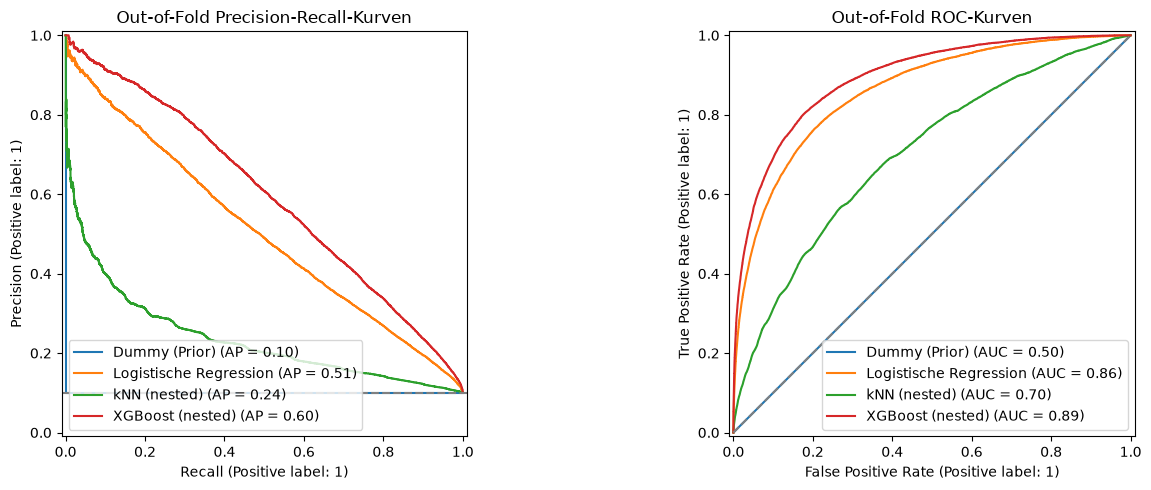

In [14]:
fold_results_df = pd.DataFrame(fold_results)

fold_summary = (
    fold_results_df.groupby("Modell")
    .agg({
        "PR-AUC": ["mean", "std"],
        "ROC-AUC": ["mean", "std"],
        "Log Loss": ["mean", "std"],
        "Brier": ["mean", "std"],
        "Sekunden": "sum",
    })
)
display(fold_summary)

oof_summary_records = []
for name in oof_predictions.columns:
    oof_summary_records.append({
        "Modell": name,
        **probability_metrics(y_dev, oof_predictions[name]),
        "Gesamtlaufzeit [min]": model_runtime[name] / 60,
    })
oof_summary = pd.DataFrame(oof_summary_records).sort_values("PR-AUC", ascending=False)
display(oof_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name in oof_predictions.columns:
    from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay
    PrecisionRecallDisplay.from_predictions(
        y_dev, oof_predictions[name], name=name, ax=axes[0]
    )
    RocCurveDisplay.from_predictions(
        y_dev, oof_predictions[name], name=name, ax=axes[1]
    )

axes[0].axhline(y_dev.mean(), color="grey", linestyle="--", label="Basisrate")
axes[0].set_title("Out-of-Fold Precision-Recall-Kurven")
axes[1].plot([0, 1], [0, 1], color="grey", linestyle="--")
axes[1].set_title("Out-of-Fold ROC-Kurven")
plt.tight_layout()
plt.show()


### 10.1 Gepaarte Bootstrap-Konfidenzintervalle auf OOF-Vorhersagen


In [15]:
def stratified_bootstrap_indices(target, repetitions=200, seed=42):
    target = np.asarray(target)
    negative_idx = np.flatnonzero(target == 0)
    positive_idx = np.flatnonzero(target == 1)
    rng = np.random.default_rng(seed)
    for _ in range(repetitions):
        sampled_negative = rng.choice(negative_idx, size=len(negative_idx), replace=True)
        sampled_positive = rng.choice(positive_idx, size=len(positive_idx), replace=True)
        yield np.concatenate([sampled_negative, sampled_positive])

bootstrap_indices = list(
    stratified_bootstrap_indices(y_dev, BOOTSTRAP_REPETITIONS, RANDOM_STATE)
)
bootstrap_records = []
for name in oof_predictions.columns:
    probabilities = oof_predictions[name].to_numpy()
    pr_values = []
    roc_values = []
    for sampled_idx in bootstrap_indices:
        pr_values.append(average_precision_score(y_dev.iloc[sampled_idx], probabilities[sampled_idx]))
        roc_values.append(roc_auc_score(y_dev.iloc[sampled_idx], probabilities[sampled_idx]))
    bootstrap_records.append({
        "Modell": name,
        "PR-AUC": average_precision_score(y_dev, probabilities),
        "PR-AUC 95%-CI": tuple(np.quantile(pr_values, [0.025, 0.975]).round(4)),
        "ROC-AUC": roc_auc_score(y_dev, probabilities),
        "ROC-AUC 95%-CI": tuple(np.quantile(roc_values, [0.025, 0.975]).round(4)),
    })

bootstrap_summary = pd.DataFrame(bootstrap_records).sort_values("PR-AUC", ascending=False)
display(bootstrap_summary)

best_model_name = bootstrap_summary.iloc[0]["Modell"]
best_probabilities = oof_predictions[best_model_name].to_numpy()

paired_differences = []
for challenger in oof_predictions.columns:
    if challenger == best_model_name:
        continue
    challenger_probabilities = oof_predictions[challenger].to_numpy()
    differences = []
    for sampled_idx in bootstrap_indices:
        differences.append(
            average_precision_score(y_dev.iloc[sampled_idx], best_probabilities[sampled_idx])
            - average_precision_score(y_dev.iloc[sampled_idx], challenger_probabilities[sampled_idx])
        )
    paired_differences.append({
        "Vergleich": f"{best_model_name} minus {challenger}",
        "PR-AUC-Differenz": average_precision_score(y_dev, best_probabilities)
        - average_precision_score(y_dev, challenger_probabilities),
        "95%-CI": tuple(np.quantile(differences, [0.025, 0.975]).round(4)),
    })

display(pd.DataFrame(paired_differences))
print("Bestes Modell nach OOF PR-AUC:", best_model_name)


,Modell,PR-AUC,PR-AUC 95%-CI,ROC-AUC,ROC-AUC 95%-CI
3,XGBoost (nested),0.5961,"(0.5889, 0.6034)",0.8930,"(0.8905, 0.8953)"
1,Logistische Regression,0.5067,"(0.4997, 0.5144)",0.8599,"(0.8569, 0.8626)"
2,kNN (nested),0.2362,"(0.2302, 0.2418)",0.7015,"(0.6973, 0.7058)"
0,Dummy (Prior),0.1005,"(0.0997, 0.1012)",0.5000,"(0.4956, 0.5039)"


,Vergleich,PR-AUC-Differenz,95%-CI
0,XGBoost (nested) minus Dummy (Prior),0.4956,"(0.4883, 0.5028)"
1,XGBoost (nested) minus Logistische Regression,0.0893,"(0.0836, 0.0947)"
2,XGBoost (nested) minus kNN (nested),0.3598,"(0.3523, 0.3672)"


Bestes Modell nach OOF PR-AUC: XGBoost (nested)


## 11. K-Means – separate explorative Clusteranalyse

Wegen der quadratischen Kosten der Silhouette-Berechnung wird K-Means auf einer vorab zufällig gezogenen Entwicklungsstichprobe untersucht und die Silhouette reproduzierbar auf höchstens 5.000 Punkten berechnet. Mehrere Seeds prüfen die Stabilität.


In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

rng = np.random.default_rng(RANDOM_STATE)
kmeans_sample_idx = np.sort(rng.choice(len(X_dev), size=40_000, replace=False))
X_kmeans_sample = X_dev.iloc[kmeans_sample_idx]
y_kmeans_sample = y_dev.iloc[kmeans_sample_idx].reset_index(drop=True)

kmeans_scaler = StandardScaler()
X_kmeans_scaled = np.asarray(
    kmeans_scaler.fit_transform(X_kmeans_sample), dtype="float32"
)

kmeans_records = []
kmeans_labels = {}
for k in KMEANS_K_VALUES:
    for seed in KMEANS_SEEDS:
        start = perf_counter()
        model = KMeans(
            n_clusters=k,
            n_init=5,
            max_iter=300,
            random_state=seed,
        )
        labels = model.fit_predict(X_kmeans_scaled)
        silhouette = silhouette_score(
            X_kmeans_scaled,
            labels,
            sample_size=5_000,
            random_state=seed,
        )
        kmeans_labels[(k, seed)] = labels
        kmeans_records.append({
            "k": k,
            "Seed": seed,
            "Inertia": model.inertia_,
            "Silhouette": silhouette,
            "Sekunden": perf_counter() - start,
        })

kmeans_results = pd.DataFrame(kmeans_records)
kmeans_stability = []
for k in KMEANS_K_VALUES:
    pairwise_ari = []
    for i, seed_a in enumerate(KMEANS_SEEDS):
        for seed_b in KMEANS_SEEDS[i + 1:]:
            pairwise_ari.append(
                adjusted_rand_score(kmeans_labels[(k, seed_a)], kmeans_labels[(k, seed_b)])
            )
    kmeans_stability.append({
        "k": k,
        "ARI Mittel": np.mean(pairwise_ari),
        "ARI Minimum": np.min(pairwise_ari),
    })

kmeans_summary = (
    kmeans_results.groupby("k")
    .agg(
        Inertia_Mittel=("Inertia", "mean"),
        Inertia_Std=("Inertia", "std"),
        Silhouette_Mittel=("Silhouette", "mean"),
        Silhouette_Std=("Silhouette", "std"),
    )
    .reset_index()
    .merge(pd.DataFrame(kmeans_stability), on="k")
)
display(kmeans_summary)


,k,Inertia_Mittel,Inertia_Std,Silhouette_Mittel,Silhouette_Std,ARI Mittel,ARI Minimum
0,2,"7,968,516.3333",17.8489,0.0042,0.0001,0.6782,0.6550
1,3,"7,947,724.3333",45.6216,0.0026,0.0001,0.2410,0.2158
2,5,"7,918,194.1667",182.7678,0.0021,0.0003,0.1089,0.0999
3,7,"7,896,492.6667",71.7850,0.0021,0.0001,0.0707,0.0636


,n,Positive,Positive Rate,Lift vs. Basisrate
Cluster,,,,
0,20987,525,0.0250,0.2489
1,19013,3488,0.1835,1.8256


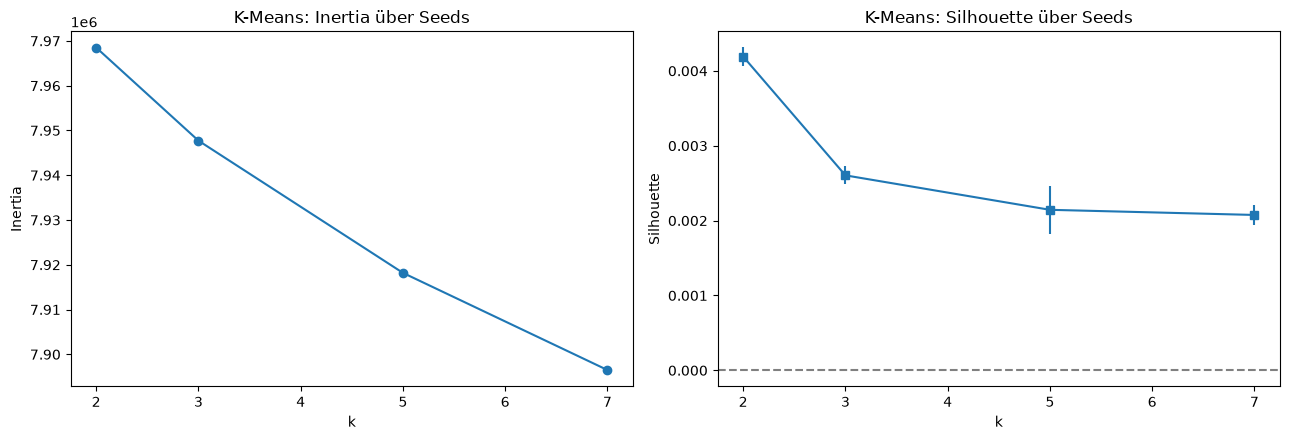

Fazit: keine überzeugend getrennte natürliche Clusterstruktur im standardisierten Raum.
Target-Anreicherung ist eine nachträgliche Beschreibung und keine kausale Interpretation.


In [17]:
best_k = int(kmeans_summary.loc[kmeans_summary["Silhouette_Mittel"].idxmax(), "k"])
reference_seed = KMEANS_SEEDS[0]
reference_labels = kmeans_labels[(best_k, reference_seed)]

cluster_target = pd.DataFrame({
    "Cluster": reference_labels,
    "Target": y_kmeans_sample,
}).groupby("Cluster")["Target"].agg(["count", "sum", "mean"])
cluster_target.columns = ["n", "Positive", "Positive Rate"]
cluster_target["Lift vs. Basisrate"] = cluster_target["Positive Rate"] / y_dev.mean()
display(cluster_target)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
kmeans_summary.plot(
    x="k", y="Inertia_Mittel", yerr="Inertia_Std", marker="o", ax=axes[0], legend=False
)
axes[0].set_title("K-Means: Inertia über Seeds")
axes[0].set_ylabel("Inertia")
kmeans_summary.plot(
    x="k", y="Silhouette_Mittel", yerr="Silhouette_Std", marker="s", ax=axes[1], legend=False
)
axes[1].axhline(0, color="grey", linestyle="--")
axes[1].set_title("K-Means: Silhouette über Seeds")
axes[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.show()

if kmeans_summary["Silhouette_Mittel"].max() < 0.05:
    print("Fazit: keine überzeugend getrennte natürliche Clusterstruktur im standardisierten Raum.")
else:
    print("Fazit: messbare Clustertrennung; Stabilität und externe Reproduzierbarkeit bleiben zu prüfen.")
print("Target-Anreicherung ist eine nachträgliche Beschreibung und keine kausale Interpretation.")


### 11.1 Out-of-sample-Prüfung der Clusteranreicherung


In [18]:
cluster_train_idx, cluster_validation_idx = train_test_split(
    np.arange(len(X_dev)),
    test_size=0.25,
    stratify=y_dev,
    random_state=RANDOM_STATE + 500,
)
cluster_scaler = StandardScaler()
X_cluster_train = cluster_scaler.fit_transform(X_dev.iloc[cluster_train_idx])
X_cluster_validation = cluster_scaler.transform(X_dev.iloc[cluster_validation_idx])

cluster_model = KMeans(
    n_clusters=best_k,
    n_init=5,
    max_iter=300,
    random_state=RANDOM_STATE,
)
train_labels = cluster_model.fit_predict(X_cluster_train)
validation_labels = cluster_model.predict(X_cluster_validation)

train_cluster_rates = (
    pd.DataFrame({"Cluster": train_labels, "Target": y_dev.iloc[cluster_train_idx].to_numpy()})
    .groupby("Cluster")["Target"]
    .mean()
)
cluster_validation_scores = pd.Series(validation_labels).map(train_cluster_rates).to_numpy()
cluster_validation_metrics = probability_metrics(
    y_dev.iloc[cluster_validation_idx], cluster_validation_scores
)
display(pd.DataFrame([cluster_validation_metrics], index=["Cluster-Rate als Post-hoc-Score"]))
print("Diese Kennzahlen prüfen nur die Reproduzierbarkeit der Segmentanreicherung; K-Means bleibt außerhalb des Klassifikator-Rankings.")


,PR-AUC,ROC-AUC,Log Loss,Brier
Cluster-Rate als Post-hoc-Score,0.1846,0.7395,0.2804,0.0828


Diese Kennzahlen prüfen nur die Reproduzierbarkeit der Segmentanreicherung; K-Means bleibt außerhalb des Klassifikator-Rankings.


## 12. Learning Curves für die führenden überwachten Modellfamilien


,Modell,Trainingsanteil,Train n,Train PR-AUC,Validation PR-AUC,Sekunden
0,Logistische Regression,0.2000,25600,0.5343,0.4877,0.2921
1,XGBoost,0.2000,25600,0.9584,0.5633,29.5625
2,Logistische Regression,0.4000,51200,0.5096,0.4959,0.4682
3,XGBoost,0.4000,51200,0.8697,0.5848,45.1802
4,Logistische Regression,0.6000,76800,0.5183,0.5010,0.6086
5,XGBoost,0.6000,76800,0.8239,0.5926,63.9488
6,Logistische Regression,0.8000,102400,0.5165,0.5008,0.7903
7,XGBoost,0.8000,102400,0.7886,0.5941,81.3060
8,Logistische Regression,1.0000,128000,0.5139,0.5025,1.2515
9,XGBoost,1.0000,128000,0.7625,0.5980,98.0501


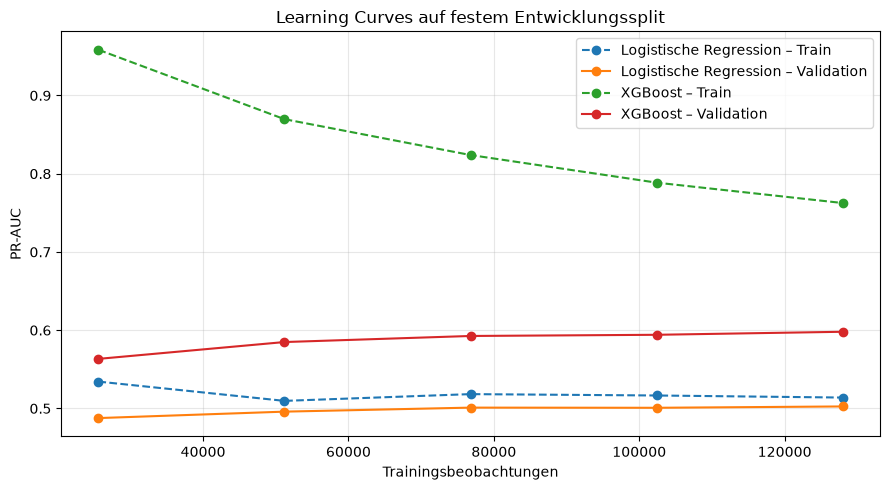

In [19]:
# Ressourcenschonende Diagnose auf einem festen, vom Holdout unabhängigen Entwicklungssplit.
learning_train_idx, learning_validation_idx = train_test_split(
    np.arange(len(X_dev)),
    test_size=0.20,
    stratify=y_dev,
    random_state=RANDOM_STATE + 600,
)
learning_fractions = [0.20, 0.40, 0.60, 0.80, 1.00]
learning_records = []

logistic_details = model_details["Logistische Regression"]
logistic_c = float(logistic_details["model__C"].mode(dropna=True).iloc[0])
balanced_count = int(logistic_details["model__class_weight"].eq("balanced").sum())
unweighted_count = int(logistic_details["model__class_weight"].isna().sum())
logistic_class_weight = "balanced" if balanced_count > unweighted_count else None
xgb_mode = model_details["XGBoost (nested)"]["Kandidat"].mode().iloc[0]
xgb_tree_count = int(model_details["XGBoost (nested)"]["Bäume"].median())

rng = np.random.default_rng(RANDOM_STATE + 601)
for fraction in learning_fractions:
    sample_size = int(len(learning_train_idx) * fraction)
    sampled_train_idx, _ = train_test_split(
        learning_train_idx,
        train_size=sample_size,
        stratify=y_dev.iloc[learning_train_idx],
        random_state=RANDOM_STATE + int(100 * fraction),
    ) if fraction < 1.0 else (learning_train_idx, None)

    models = {
        "Logistische Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                C=logistic_c,
                class_weight=logistic_class_weight,
                solver="lbfgs",
                max_iter=1_000,
                random_state=RANDOM_STATE,
            )),
        ]),
        "XGBoost": XGBClassifier(
            **XGB_COMMON,
            **XGB_CANDIDATES[xgb_mode],
            n_estimators=xgb_tree_count,
        ),
    }

    for name, model in models.items():
        start = perf_counter()
        model.fit(X_dev.iloc[sampled_train_idx], y_dev.iloc[sampled_train_idx])
        train_probability = model.predict_proba(X_dev.iloc[sampled_train_idx])[:, 1]
        validation_probability = model.predict_proba(X_dev.iloc[learning_validation_idx])[:, 1]
        learning_records.append({
            "Modell": name,
            "Trainingsanteil": fraction,
            "Train n": len(sampled_train_idx),
            "Train PR-AUC": average_precision_score(y_dev.iloc[sampled_train_idx], train_probability),
            "Validation PR-AUC": average_precision_score(y_dev.iloc[learning_validation_idx], validation_probability),
            "Sekunden": perf_counter() - start,
        })

learning_results = pd.DataFrame(learning_records)
display(learning_results)

fig, ax = plt.subplots(figsize=(9, 5))
for name, group in learning_results.groupby("Modell"):
    ax.plot(group["Train n"], group["Train PR-AUC"], marker="o", linestyle="--", label=f"{name} – Train")
    ax.plot(group["Train n"], group["Validation PR-AUC"], marker="o", label=f"{name} – Validation")
ax.set_title("Learning Curves auf festem Entwicklungssplit")
ax.set_xlabel("Trainingsbeobachtungen")
ax.set_ylabel("PR-AUC")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 13. Kalibrierung des besten OOF-Modells


,Kalibrierung,PR-AUC,ROC-AUC,Log Loss,Brier
1,Sigmoid (cross-fitted),0.5960,0.8930,0.2072,0.0594
2,Isotonic (cross-fitted),0.5926,0.8924,0.2074,0.0594
0,Roh,0.5961,0.8930,0.2112,0.0605


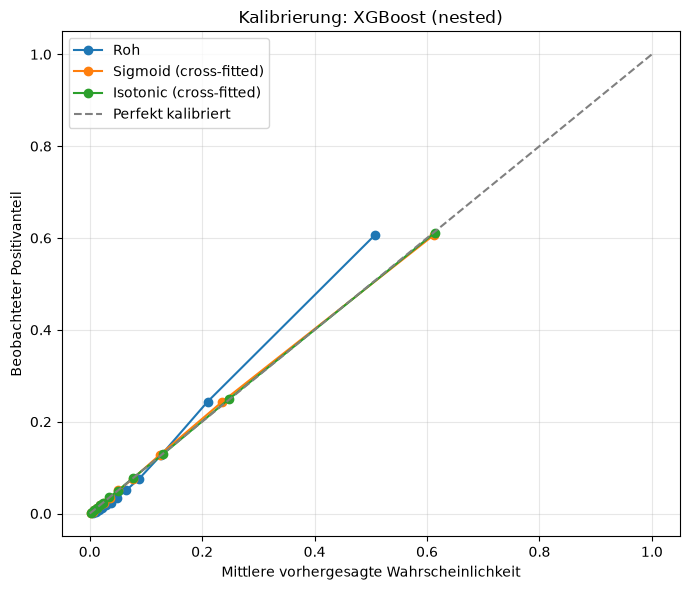

Kalibrierung mit niedrigstem OOF Log Loss: Sigmoid (cross-fitted)


In [20]:
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression

def probability_logit(probabilities):
    probabilities = np.clip(np.asarray(probabilities), 1e-6, 1 - 1e-6)
    return np.log(probabilities / (1 - probabilities))

calibration_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE + 700)
raw_best = oof_predictions[best_model_name].to_numpy()
sigmoid_crossfit = np.full(len(y_dev), np.nan)
isotonic_crossfit = np.full(len(y_dev), np.nan)

for train_idx, validation_idx in calibration_cv.split(raw_best.reshape(-1, 1), y_dev):
    sigmoid = LogisticRegression(C=1e6, solver="lbfgs")
    sigmoid.fit(probability_logit(raw_best[train_idx]).reshape(-1, 1), y_dev.iloc[train_idx])
    sigmoid_crossfit[validation_idx] = sigmoid.predict_proba(
        probability_logit(raw_best[validation_idx]).reshape(-1, 1)
    )[:, 1]

    isotonic = IsotonicRegression(out_of_bounds="clip")
    isotonic.fit(raw_best[train_idx], y_dev.iloc[train_idx])
    isotonic_crossfit[validation_idx] = isotonic.predict(raw_best[validation_idx])

calibration_candidates = {
    "Roh": raw_best,
    "Sigmoid (cross-fitted)": sigmoid_crossfit,
    "Isotonic (cross-fitted)": isotonic_crossfit,
}
calibration_records = []
for name, probabilities in calibration_candidates.items():
    calibration_records.append({"Kalibrierung": name, **probability_metrics(y_dev, probabilities)})
calibration_results = pd.DataFrame(calibration_records).sort_values("Log Loss")
display(calibration_results)

fig, ax = plt.subplots(figsize=(7, 6))
for name, probabilities in calibration_candidates.items():
    observed, predicted = calibration_curve(y_dev, probabilities, n_bins=12, strategy="quantile")
    ax.plot(predicted, observed, marker="o", label=name)
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Perfekt kalibriert")
ax.set_title(f"Kalibrierung: {best_model_name}")
ax.set_xlabel("Mittlere vorhergesagte Wahrscheinlichkeit")
ax.set_ylabel("Beobachteter Positivanteil")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_calibration_name = calibration_results.iloc[0]["Kalibrierung"]
decision_probabilities = calibration_candidates[best_calibration_name]
print("Kalibrierung mit niedrigstem OOF Log Loss:", best_calibration_name)


## 14. OOF-basierte Schwellenwertanalyse


,Policy,Schwellenwert,Precision,Recall,F1,Als positiv klassifiziert [%]
0,Maximales F1,0.2780,0.5520,0.5699,0.5608,10.3756
1,Beste Precision bei Recall ≥ 0.80,0.1026,0.3375,0.8000,0.4747,23.8194


,Prognose 0,Prognose 1
Maximales F1,,
Ist 0,136484,7438
Ist 1,6915,9163


,Prognose 0,Prognose 1
Beste Precision bei Recall ≥ 0.80,,
Ist 0,118674,25248
Ist 1,3215,12863


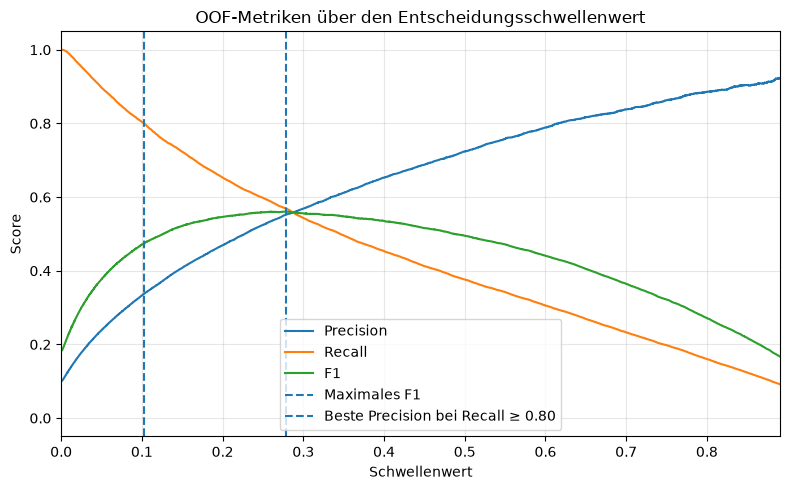

Ohne fachliche Fehlerkosten wird keine der beiden Policies als endgültige Geschäftsregel ausgegeben.


In [21]:
from sklearn.metrics import precision_recall_curve, confusion_matrix, precision_score, recall_score, f1_score

precision, recall, thresholds = precision_recall_curve(y_dev, decision_probabilities)
f1_values = 2 * precision[:-1] * recall[:-1] / np.maximum(precision[:-1] + recall[:-1], 1e-12)
best_f1_idx = int(np.nanargmax(f1_values))

eligible_high_recall = np.flatnonzero(recall[:-1] >= 0.80)
high_recall_idx = eligible_high_recall[np.argmax(precision[:-1][eligible_high_recall])]

threshold_policies = {
    "Maximales F1": float(thresholds[best_f1_idx]),
    "Beste Precision bei Recall ≥ 0.80": float(thresholds[high_recall_idx]),
}

threshold_records = []
confusion_matrices = {}
for policy, threshold in threshold_policies.items():
    predictions = (decision_probabilities >= threshold).astype(int)
    confusion_matrices[policy] = confusion_matrix(y_dev, predictions)
    threshold_records.append({
        "Policy": policy,
        "Schwellenwert": threshold,
        "Precision": precision_score(y_dev, predictions),
        "Recall": recall_score(y_dev, predictions),
        "F1": f1_score(y_dev, predictions),
        "Als positiv klassifiziert [%]": 100 * predictions.mean(),
    })

threshold_results = pd.DataFrame(threshold_records)
display(threshold_results)
for policy, matrix in confusion_matrices.items():
    display(pd.DataFrame(matrix, index=["Ist 0", "Ist 1"], columns=["Prognose 0", "Prognose 1"]).rename_axis(policy))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, precision[:-1], label="Precision")
ax.plot(thresholds, recall[:-1], label="Recall")
ax.plot(thresholds, f1_values, label="F1")
for policy, threshold in threshold_policies.items():
    ax.axvline(threshold, linestyle="--", label=policy)
ax.set_title("OOF-Metriken über den Entscheidungsschwellenwert")
ax.set_xlabel("Schwellenwert")
ax.set_ylabel("Score")
ax.set_xlim(0, np.quantile(thresholds, 0.99))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Ohne fachliche Fehlerkosten wird keine der beiden Policies als endgültige Geschäftsregel ausgegeben.")


## 15. XGBoost-Interpretation: Gain-Stabilität und Validierungs-Permutation


,Gain Mittel,Gain Std,Gain Rang Std,|Cohen's d|,|Pearson|
var_81,0.0231,0.0016,0.0000,0.2671,0.0800
var_139,0.0169,0.0013,0.0000,0.2438,0.0731
var_12,0.0149,0.0009,0.4472,0.2338,0.0701
var_110,0.0138,0.0008,1.5166,0.2155,0.0647
var_26,0.0132,0.0004,0.7071,0.2088,0.0627
var_53,0.0130,0.0006,1.1402,0.2118,0.0636
var_80,0.0121,0.0008,1.4832,0.1931,0.0579
var_146,0.0118,0.0008,3.1623,0.2184,0.0655
var_6,0.0115,0.0003,0.7071,0.2309,0.0693
var_109,0.0112,0.0003,1.3038,0.1671,0.0502


,Feature,PR-AUC-Abfall Mittel,PR-AUC-Abfall Std
2,var_12,0.0227,0.0055
0,var_81,0.0219,0.0027
3,var_110,0.0177,0.0014
10,var_166,0.0170,0.0081
12,var_99,0.0169,0.0038
11,var_174,0.0165,0.0060
8,var_6,0.0150,0.0041
14,var_22,0.0149,0.0014
1,var_139,0.0145,0.0031
18,var_44,0.0137,0.0027


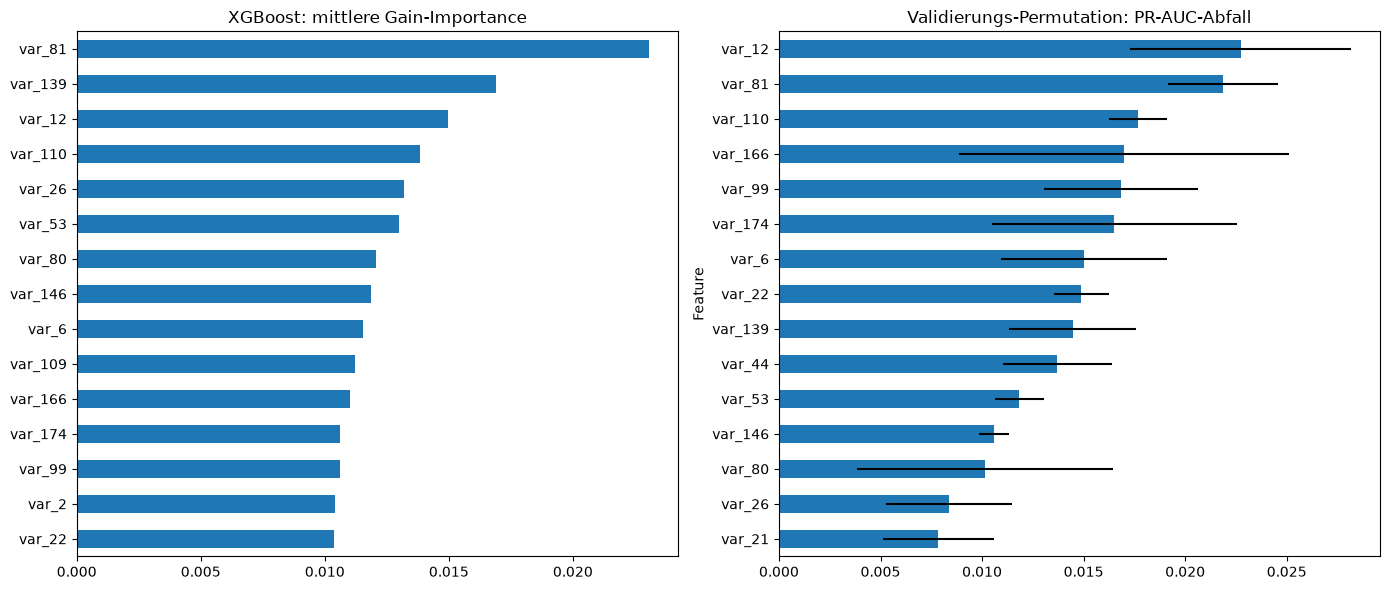

Importances sind modellabhängige Assoziationen und keine kausalen Effekte.


In [22]:
gain_array = np.vstack(xgb_gain_importances)
gain_table = pd.DataFrame({
    "Gain Mittel": gain_array.mean(axis=0),
    "Gain Std": gain_array.std(axis=0, ddof=1),
    "Gain Rang Std": pd.DataFrame(gain_array).rank(axis=1, ascending=False).std(axis=0).to_numpy(),
    "|Cohen's d|": association.loc[X_dev.columns, "|Cohen's d|"].to_numpy(),
    "|Pearson|": association.loc[X_dev.columns, "|Pearson|"].to_numpy(),
}, index=X_dev.columns).sort_values("Gain Mittel", ascending=False)

display(gain_table.head(20))

# Begrenzte Permutationsprüfung auf den 20 führenden Gain-Features im letzten äußeren Fold.
permutation_features = gain_table.head(20).index.tolist()
permutation_rng = np.random.default_rng(RANDOM_STATE + 800)
validation_artifact = xgb_last_fold_artifact
sample_size = min(5_000, len(validation_artifact["X_validation"]))
sample_positions = permutation_rng.choice(
    len(validation_artifact["X_validation"]), size=sample_size, replace=False
)
X_permutation = validation_artifact["X_validation"].iloc[sample_positions].copy()
y_permutation = validation_artifact["y_validation"].iloc[sample_positions]
base_probability = validation_artifact["model"].predict_proba(X_permutation)[:, 1]
base_pr_auc = average_precision_score(y_permutation, base_probability)

permutation_records = []
for feature in permutation_features:
    drops = []
    original_values = X_permutation[feature].to_numpy(copy=True)
    for _ in range(3):
        X_permutation[feature] = permutation_rng.permutation(original_values)
        permuted_probability = validation_artifact["model"].predict_proba(X_permutation)[:, 1]
        drops.append(base_pr_auc - average_precision_score(y_permutation, permuted_probability))
    X_permutation[feature] = original_values
    permutation_records.append({
        "Feature": feature,
        "PR-AUC-Abfall Mittel": np.mean(drops),
        "PR-AUC-Abfall Std": np.std(drops, ddof=1),
    })

permutation_table = pd.DataFrame(permutation_records).sort_values(
    "PR-AUC-Abfall Mittel", ascending=False
)
display(permutation_table)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
gain_table.head(15).sort_values("Gain Mittel")["Gain Mittel"].plot(kind="barh", ax=axes[0])
axes[0].set_title("XGBoost: mittlere Gain-Importance")
permutation_table.head(15).sort_values("PR-AUC-Abfall Mittel").plot(
    x="Feature", y="PR-AUC-Abfall Mittel", xerr="PR-AUC-Abfall Std",
    kind="barh", ax=axes[1], legend=False
)
axes[1].set_title("Validierungs-Permutation: PR-AUC-Abfall")
plt.tight_layout()
plt.show()

print("Importances sind modellabhängige Assoziationen und keine kausalen Effekte.")


## 16. Ergebniszusammenfassung und Modellentscheidung vor dem Holdout


In [23]:
best_oof_row = oof_summary.iloc[0]
runner_up_row = oof_summary.iloc[1]
best_fold_rows = fold_results_df[fold_results_df["Modell"] == best_model_name]

print("KERNERGEBNISSE")
print("=" * 80)
print(f"Bestes Modell nach OOF PR-AUC: {best_model_name}")
print(f"OOF PR-AUC:  {best_oof_row['PR-AUC']:.4f}")
print(f"OOF ROC-AUC: {best_oof_row['ROC-AUC']:.4f}")
print(f"Fold-Streuung PR-AUC: {best_fold_rows['PR-AUC'].std(ddof=1):.4f}")
print(f"Vorsprung zur zweitbesten OOF PR-AUC: {best_oof_row['PR-AUC'] - runner_up_row['PR-AUC']:.4f}")
print(f"Gewählte Kalibrierungsvariante nach OOF Log Loss: {best_calibration_name}")
print()
print("METHODISCHE EINORDNUNG")
print("- Modellwahl basiert ausschließlich auf Entwicklungsdaten und OOF-Vorhersagen.")
print("- kNN und XGBoost werden mit innerer Auswahl und äußerer Evaluation bewertet.")
print("- K-Means wird separat als exploratives Clustering interpretiert.")
print("- Der finale Holdout wurde nicht ausgewertet.")


KERNERGEBNISSE
Bestes Modell nach OOF PR-AUC: XGBoost (nested)
OOF PR-AUC:  0.5961
OOF ROC-AUC: 0.8930
Fold-Streuung PR-AUC: 0.0037
Vorsprung zur zweitbesten OOF PR-AUC: 0.0893
Gewählte Kalibrierungsvariante nach OOF Log Loss: Sigmoid (cross-fitted)

METHODISCHE EINORDNUNG
- Modellwahl basiert ausschließlich auf Entwicklungsdaten und OOF-Vorhersagen.
- kNN und XGBoost werden mit innerer Auswahl und äußerer Evaluation bewertet.
- K-Means wird separat als exploratives Clustering interpretiert.
- Der finale Holdout wurde nicht ausgewertet.


### Limitationen

- Die 200 Features sind anonymisiert; fachliche und kausale Interpretationen sind nicht möglich.
- Der Holdout stammt aus demselben ursprünglichen Datensatz und ist daher kein vollständig externer Datensatz.
- Die kNN-Suche ist wegen der hohen Rechenkosten bewusst kompakt und verwendet pro äußerem Fold 10.000 stratifiziert gezogene Trainingsfälle. Der äußere Validation-Fold wird vollständig und ohne Auswahlzugriff ausgewertet.
- Die XGBoost-Kandidatenauswahl untersucht einen vorab begrenzten Suchraum und ist kein unbegrenztes Optimierungsverfahren.
- K-Means-Silhouette und Stabilität werden auf einer reproduzierbaren Entwicklungsstichprobe geprüft.
- Schwellenwert-Policies bleiben Szenarien, solange keine fachlichen Kosten für False Positives und False Negatives vorliegen.


## 17. Harte Holdout-Sperre


In [24]:
ALLOW_FINAL_HOLDOUT_EVALUATION = False

if ALLOW_FINAL_HOLDOUT_EVALUATION:
    raise RuntimeError(
        "Holdout-Auswertung ist in v5 absichtlich nicht implementiert. "
        "Zuerst Modell, Kalibrierung und Schwellenwert schriftlich festschreiben "
        "und anschließend eine separate finale Notebook-Version erzeugen."
    )

print("Finaler Holdout bleibt GESPERRT.")
print(f"Vorhandene, nicht ausgewertete Holdout-Beobachtungen: {len(X_final_holdout):,}")
print("Keine Holdout-Zielverteilung, keine Vorhersage und keine Metrik wurde berechnet.")


Finaler Holdout bleibt GESPERRT.
Vorhandene, nicht ausgewertete Holdout-Beobachtungen: 40,000
Keine Holdout-Zielverteilung, keine Vorhersage und keine Metrik wurde berechnet.


## Nächster kontrollierter Schritt

Nach fachlicher Prüfung dieses vollständig ausgeführten Notebooks werden folgende Entscheidungen schriftlich eingefroren:

1. finale Modellfamilie und Hyperparameter,
2. finale Baumzahl beziehungsweise Trainingsregel,
3. Kalibrierungsverfahren,
4. Entscheidungsschwellenwert oder reine Ranking-Nutzung,
5. finale Metriken.

Erst danach darf eine separate Finalversion das Modell auf allen Entwicklungsdaten trainieren und den Holdout genau einmal auswerten. Nach dieser Auswertung findet kein weiteres Tuning am selben Holdout statt.
